**Computación Cuántica II**
# Sebastián González Juárez
Práctica de laboratorio 3.

# **1. Bernstein-Vazirani (C)**

In [40]:
!pip install qiskit qiskit-aer pylatexenc matplotlib

In [41]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Construcción del circuito sin usar bv_oracle(n,s).

In [42]:
def bernstein_vazirani_manual(s):
    n = len(s)
    qc = QuantumCircuit(n + 1, n)

    # 1) Preparar el qubit auxiliar en |1>
    qc.x(n)

    # 2) Aplicar Hadamard a todos los qubits
    qc.h(range(n + 1))

    # 3) Construir manualmente el oráculo (Se recorre s al revés por el orden de lectura de Qiskit)
    s_reversa = s[::-1]
    for i, bit in enumerate(s_reversa):
        if bit == "1":
            qc.cx(i, n)

    # 4) Aplicar Hadamard otra vez al registro de entrada
    qc.h(range(n))

    # 5) Medir el registro de entrada
    qc.measure(range(n), range(n))

    return qc

Función para dibujar y ejecutar:

In [43]:
def ejecutar_caso_bv(s, shots=1024):
    simulator = AerSimulator()

    # Construcción del circuito
    qc = bernstein_vazirani_manual(s)

    # Mostrar circuito
    print(f"\nCircuito para s = {s}")
    display(qc.draw(output="mpl"))

    # Ejecución
    tqc = transpile(qc, simulator)
    result = simulator.run(tqc, shots=shots).result()
    counts = result.get_counts()

    # Mostrar resultados
    print(f"Resultados para s = {s}: {counts}")
    display(plot_histogram(counts))

    return qc, counts

Caso: s=0110


Circuito para s = 0110


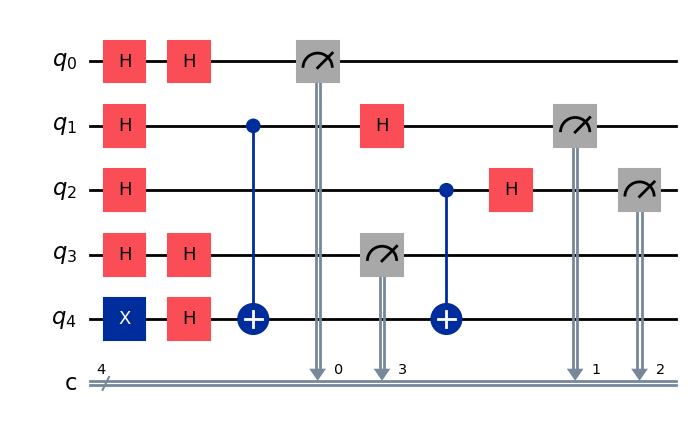

Resultados para s = 0110: {'0110': 1024}


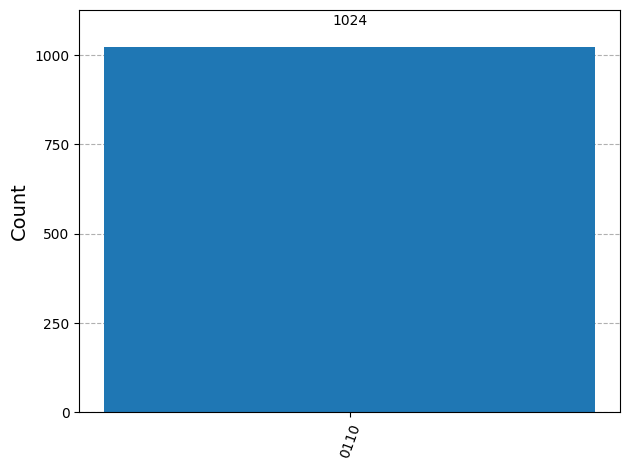

In [44]:
qc_0110, counts_0110 = ejecutar_caso_bv("0110", shots=1024)

En este caso el string oculto es 0110 significa que solo dos bits del string son 1, así que el oráculo colocará dos compuertas CNOT hacia el qubit auxiliar. Todo lo demás en el algoritmo permanece igual. Después de la segunda capa de Hadamards, el estado final del registro principal debe corresponder a ∣0110⟩, por lo que al medir se espera recuperar ese mismo string.

Caso: s=1101


Circuito para s = 1101


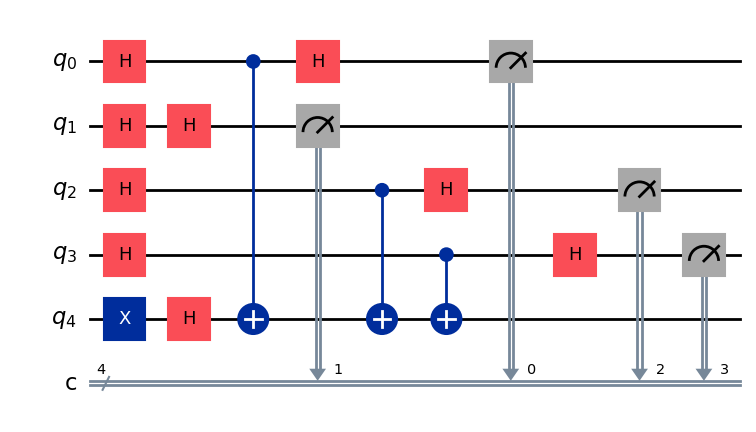

Resultados para s = 1101: {'1101': 1024}


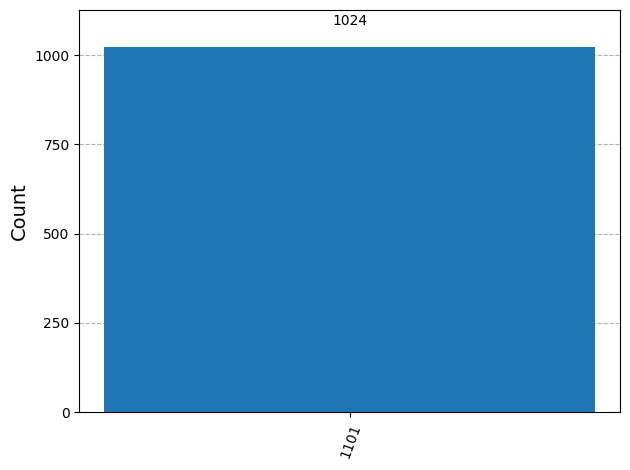

In [45]:
qc_1101, counts_1101 = ejecutar_caso_bv("1101", shots=1024)

Ahora el string oculto es 1101 y el procedimiento no cambia. Lo único distinto es qué posiciones del string tienen valor 1, porque esas son las que determinan dónde se ponen las compuertas CNOT del oráculo. Al ejecutar el circuito, la medición debe concentrarse en el resultado 1101.

Caso: s=1111


Circuito para s = 1111


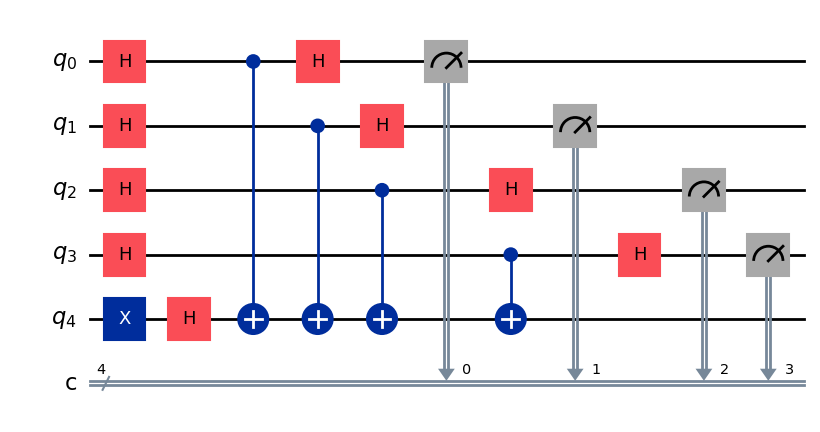

Resultados para s = 1111: {'1111': 1024}


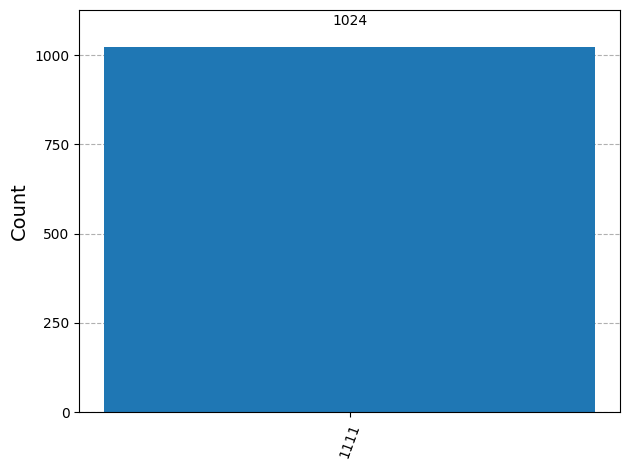

In [46]:
qc_1111, counts_1111 = ejecutar_caso_bv("1111", shots=1024)

En este caso todos los bits del string son 1. Por lo tanto, el oráculo colocará una compuerta CNOT desde cada qubit del registro de entrada hacia el qubit auxiliar. Nuevamente, la estructura del algoritmo es exactamente la misma. Como el string oculto es 1111, eso es lo que debe aparecer al final en la medición.

Caso 4: s=1010


Circuito para s = 1010


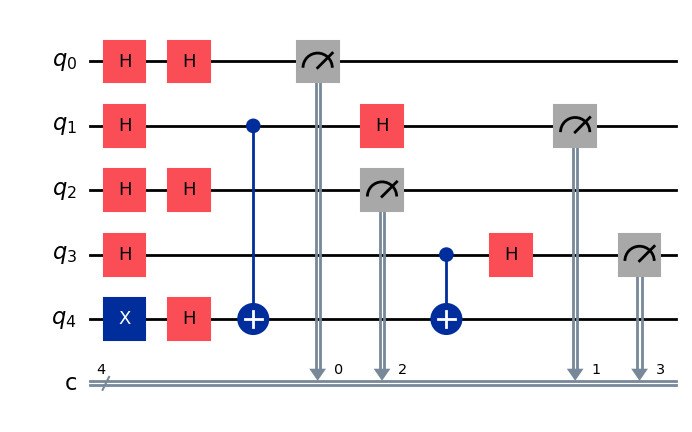

Resultados para s = 1010: {'1010': 1024}


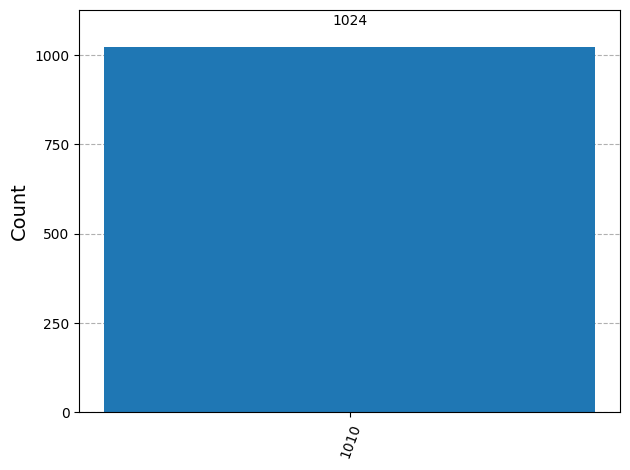

In [47]:
qc_1010, counts_1010 = ejecutar_caso_bv("1010", shots=1024)

Finalmente, para 1010, el circuito sigue el mismo patrón. Solo cambian las posiciones donde se insertan las CNOT del oráculo. Este ejemplo confirma que el algoritmo no depende de un string específico, sino de la misma construcción general. La medición esperada debe ser 1010.

Comparación final de todos los casos:

In [48]:
resultados = {
    "0110": counts_0110,
    "1101": counts_1101,
    "1111": counts_1111,
    "1010": counts_1010
}

for s, counts in resultados.items():
    print(f"{s} -> {counts}")

0110 -> {'0110': 1024}
1101 -> {'1101': 1024}
1111 -> {'1111': 1024}
1010 -> {'1010': 1024}


Por lo tanto:

Para cada uno de los strings $s = 0110$, $s = 1101$, $s = 1111$ y $s = 1010$, el algoritmo de Bernstein–Vazirani se implementó siguiendo exactamente la misma estructura. Primero se preparó el qubit auxiliar en el estado $|1\rangle$, después se aplicaron compuertas Hadamard a todos los qubits y se construyó manualmente el oráculo sin usar la función `bv_oracle(n,s)`. Este oráculo se armó colocando compuertas CNOT únicamente en las posiciones donde el string oculto tiene bits iguales a 1, de modo que se implementa la función $f_s(x) = s \cdot x \ (\text{mod } 2)$. Luego se aplicaron nuevamente compuertas Hadamard al registro de entrada y se realizó la medición. En todos los casos, el resultado dominante coincidió con el string oculto correspondiente, lo que confirma que el algoritmo recupera correctamente $s$ en una sola ejecución ideal del circuito.

# **2. Simon (b)**


In [80]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Utilidades

In [81]:
def xor_bits(a, b):
    return ''.join(str(int(x) ^ int(y)) for x, y in zip(a, b))

def dot_mod2(a, b):
    return sum(int(x) * int(y) for x, y in zip(a, b)) % 2

def rank_mod2(rows):
    A = [list(map(int, r)) for r in rows if r != "0000"]
    if not A:
        return 0
    m = len(A)
    n = len(A[0])
    r = 0
    c = 0
    while r < m and c < n:
        piv = None
        for i in range(r, m):
            if A[i][c] == 1:
                piv = i
                break
        if piv is None:
            c += 1
            continue
        A[r], A[piv] = A[piv], A[r]
        for i in range(m):
            if i != r and A[i][c] == 1:
                A[i] = [(x ^ y) for x, y in zip(A[i], A[r])]
        r += 1
        c += 1
    return r

def solve_simon_system(equations, n=4):
    eqs = [e for e in equations if e != "0000"]
    candidates = []
    for i in range(1, 2**n):
        s = format(i, f"0{n}b")
        ok = True
        for y in eqs:
            if dot_mod2(y, s) != 0:
                ok = False
                break
        if ok:
            candidates.append(s)
    return candidates

Tabla 2-a-1

In [82]:
def build_two_to_one_table(s):
    n = len(s)
    used = set()
    reps = []
    for i in range(2**n):
        x = format(i, f"0{n}b")
        x2 = xor_bits(x, s)
        if x in used or x2 in used:
            continue
        reps.append(x)
        used.add(x)
        used.add(x2)
    labels = [format(i, f"0{n}b") for i in range(len(reps))]
    table = {}
    for rep, label in zip(reps, labels):
        pair = xor_bits(rep, s)
        table[rep] = label
        table[pair] = label
    return table

def verify_two_to_one(table, s):
    ok_pair = True
    for x in table:
        if table[x] != table[xor_bits(x, s)]:
            ok_pair = False
            break
    buckets = {}
    for x, y in table.items():
        buckets.setdefault(y, []).append(x)
    ok_two_to_one = (len(buckets) == 8) and all(len(v) == 2 for v in buckets.values())
    return ok_pair and ok_two_to_one

Oráculo

In [83]:
def apply_x_mask_for_string(qc, reg, bitstring):
    n = len(bitstring)
    for j, bit in enumerate(bitstring):
        if bit == "0":
            qc.x(reg[n - 1 - j])

def controlled_write_output(qc, in_reg, out_reg, x, y):
    n = len(x)
    apply_x_mask_for_string(qc, in_reg, x)
    controls = [in_reg[i] for i in range(n)]
    for j, bit in enumerate(y):
        if bit == "1":
            qc.mcx(controls, out_reg[n - 1 - j])
    apply_x_mask_for_string(qc, in_reg, x)

def simon_oracle_from_table(table, n=4):
    xreg = QuantumRegister(n, "x")
    yreg = QuantumRegister(n, "y")
    qc = QuantumCircuit(xreg, yreg, name="Uf")
    for x in sorted(table.keys()):
        y = table[x]
        controlled_write_output(qc, xreg, yreg, x, y)
    return qc


Circuito

In [84]:
def build_simon_circuit_from_table(table, n=4):
    xreg = QuantumRegister(n, "x")
    yreg = QuantumRegister(n, "y")
    creg = ClassicalRegister(n, "c")
    qc = QuantumCircuit(xreg, yreg, creg)
    qc.h(xreg)
    oracle = simon_oracle_from_table(table, n)
    qc.compose(oracle, qubits=list(range(2 * n)), inplace=True)
    qc.h(xreg)
    qc.measure(xreg, creg)
    return qc

Ejecución

In [85]:
simulator = AerSimulator()

def one_shot_y(table, n=4):
    qc = build_simon_circuit_from_table(table, n)
    job = simulator.run(qc, shots=1)
    counts = job.result().get_counts()
    y = list(counts.keys())[0]
    return y, qc

def recover_s_with_simon(table, n=4, max_tries=60):
    equations = []
    eq_set = set()
    counts_all = {}
    last_qc = None

    for _ in range(max_tries):
        y, qc = one_shot_y(table, n)
        last_qc = qc

        counts_all[y] = counts_all.get(y, 0) + 1

        if y not in eq_set:
            eq_set.add(y)
            equations.append(y)

        candidates = solve_simon_system(equations, n=n)

        if len(candidates) == 1:
            recovered = candidates[0]
            return recovered, equations, counts_all, last_qc

    candidates = solve_simon_system(equations, n=n)
    recovered = candidates[0] if len(candidates) == 1 else None
    return recovered, equations, counts_all, last_qc

Casos

In [86]:
secrets = ["1010", "1101", "1111"]
tables = {s: build_two_to_one_table(s) for s in secrets}

Verificación

In [87]:
print("VERIFICACIÓN DE ORÁCULOS\n")
for s in secrets:
    ok = verify_two_to_one(tables[s], s)
    print(f"s = {s} -> 2-a-1 válido: {ok}")

VERIFICACIÓN DE ORÁCULOS

s = 1010 -> 2-a-1 válido: True
s = 1101 -> 2-a-1 válido: True
s = 1111 -> 2-a-1 válido: True


Resultados

In [88]:
results = {}

for s in secrets:
    recovered, equations, counts_all, qc = recover_s_with_simon(tables[s], n=4)

    results[s] = {
        "recovered": recovered,
        "equations": equations,
        "counts": counts_all
    }

    print(f"--- Caso s = {s} ---")
    print("Mediciones acumuladas:", counts_all)
    print("Ecuaciones independientes (y):")
    for eq in equations:
        print(" ", eq)
    print("Candidatos para s:", solve_simon_system(equations, n=4))
    print("String recuperado:", recovered)
    print("Rango del sistema:", rank_mod2(equations))
    print()


--- Caso s = 1010 ---
Mediciones acumuladas: {'1011': 3, '1111': 1, '0000': 1, '0101': 1}
Ecuaciones independientes (y):
  1011
  1111
  0000
  0101
Candidatos para s: ['1010']
String recuperado: 1010
Rango del sistema: 3

--- Caso s = 1101 ---
Mediciones acumuladas: {'1001': 2, '0000': 1, '0101': 2, '0111': 1}
Ecuaciones independientes (y):
  1001
  0000
  0101
  0111
Candidatos para s: ['1101']
String recuperado: 1101
Rango del sistema: 3

--- Caso s = 1111 ---
Mediciones acumuladas: {'1010': 1, '1100': 1, '1001': 1}
Ecuaciones independientes (y):
  1010
  1100
  1001
Candidatos para s: ['1111']
String recuperado: 1111
Rango del sistema: 3



Histogramas

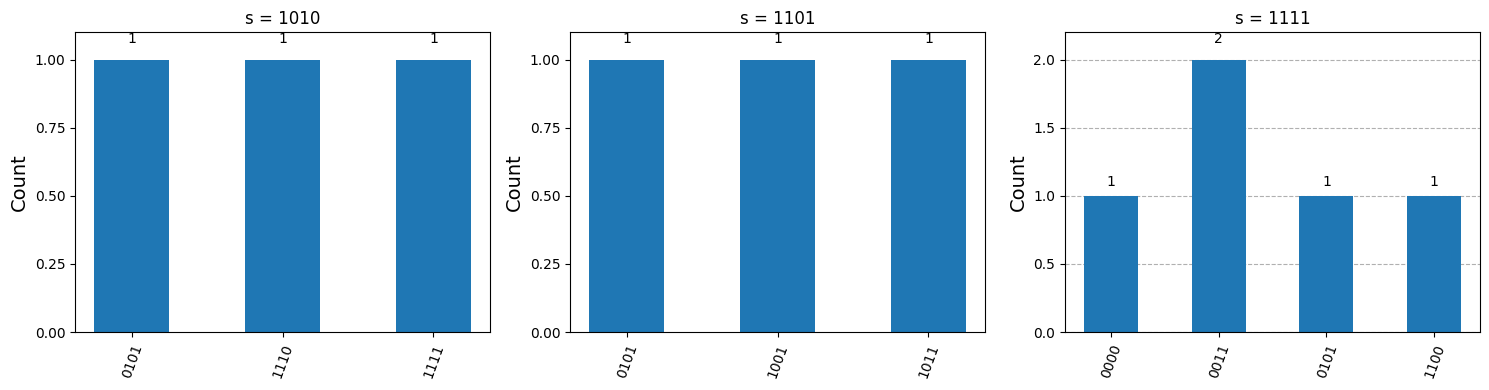

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, s in zip(axes, secrets):
    plot_histogram(results[s]["counts"], ax=ax)
    ax.set_title(f"s = {s}")

plt.tight_layout()
plt.show()


# **2. Simon (d)**

In [91]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Utilidades

In [92]:
def xor_bits(a, b):
    return ''.join(str(int(x) ^ int(y)) for x, y in zip(a, b))

def dot_mod2(a, b):
    return sum(int(x) * int(y) for x, y in zip(a, b)) % 2

Tablas de funciones 1-a-1 y 2-a-1

In [93]:
def build_one_to_one_table_identity(n=4):
    table = {}
    for i in range(2**n):
        x = format(i, f"0{n}b")
        table[x] = x
    return table

def build_one_to_one_table_reverse(n=4):
    table = {}
    for i in range(2**n):
        x = format(i, f"0{n}b")
        table[x] = x[::-1]
    return table

def build_two_to_one_table(s):
    n = len(s)
    used = set()
    reps = []
    for i in range(2**n):
        x = format(i, f"0{n}b")
        x2 = xor_bits(x, s)
        if x in used or x2 in used:
            continue
        reps.append(x)
        used.add(x)
        used.add(x2)

    labels = [format(i, f"0{n}b") for i in range(len(reps))]
    table = {}
    for rep, label in zip(reps, labels):
        pair = xor_bits(rep, s)
        table[rep] = label
        table[pair] = label
    return table

def is_one_to_one(table):
    values = list(table.values())
    return len(set(values)) == len(values)

def is_two_to_one(table):
    buckets = {}
    for x, y in table.items():
        buckets.setdefault(y, []).append(x)
    return all(len(v) == 2 for v in buckets.values())

Oráculo

In [94]:
def apply_x_mask_for_string(qc, reg, bitstring):
    n = len(bitstring)
    for j, bit in enumerate(bitstring):
        if bit == "0":
            qc.x(reg[n - 1 - j])

def controlled_write_output(qc, in_reg, out_reg, x, y):
    n = len(x)
    apply_x_mask_for_string(qc, in_reg, x)
    controls = [in_reg[i] for i in range(n)]
    for j, bit in enumerate(y):
        if bit == "1":
            qc.mcx(controls, out_reg[n - 1 - j])
    apply_x_mask_for_string(qc, in_reg, x)

def simon_oracle_from_table(table, n=4):
    xreg = QuantumRegister(n, "x")
    yreg = QuantumRegister(n, "y")
    qc = QuantumCircuit(xreg, yreg, name="Uf")
    for x in sorted(table.keys()):
        y = table[x]
        controlled_write_output(qc, xreg, yreg, x, y)
    return qc

Simon circuito

In [95]:
def build_simon_circuit(table, n=4):
    xreg = QuantumRegister(n, "x")
    yreg = QuantumRegister(n, "y")
    creg = ClassicalRegister(n, "c")
    qc = QuantumCircuit(xreg, yreg, creg)

    qc.h(xreg)
    oracle = simon_oracle_from_table(table, n)
    qc.compose(oracle, qubits=list(range(2 * n)), inplace=True)
    qc.h(xreg)
    qc.measure(xreg, creg)

    return qc

Ejecución

In [96]:
simulator = AerSimulator()

def run_simon_counts(table, shots=2048, n=4):
    qc = build_simon_circuit(table, n)
    job = simulator.run(qc, shots=shots)
    counts = job.result().get_counts()
    return qc, counts

Def. de los 4 oráculos

In [97]:
oracle_specs = {
    "1-a-1 identidad": build_one_to_one_table_identity(4),
    "1-a-1 reversa": build_one_to_one_table_reverse(4),
    "2-a-1 con s=1010": build_two_to_one_table("1010"),
    "2-a-1 con s=1111": build_two_to_one_table("1111"),
}

Verificación del tipo de función

In [98]:
print("VERIFICACIÓN DE LOS ORÁCULOS\n")
for name, table in oracle_specs.items():
    print(name)
    print("  Es 1-a-1:", is_one_to_one(table))
    print("  Es 2-a-1:", is_two_to_one(table))
    print()

VERIFICACIÓN DE LOS ORÁCULOS

1-a-1 identidad
  Es 1-a-1: True
  Es 2-a-1: False

1-a-1 reversa
  Es 1-a-1: True
  Es 2-a-1: False

2-a-1 con s=1010
  Es 1-a-1: False
  Es 2-a-1: True

2-a-1 con s=1111
  Es 1-a-1: False
  Es 2-a-1: True



Correr Simon para cada oráculo

In [99]:
results = {}

print("RESULTADOS DE LAS MEDICIONES\n")
for name, table in oracle_specs.items():
    qc, counts = run_simon_counts(table, shots=2048, n=4)
    results[name] = {"circuit": qc, "counts": counts}

    print(name)
    print("  Counts:", counts)
    print()

RESULTADOS DE LAS MEDICIONES

1-a-1 identidad
  Counts: {'1110': 115, '0001': 134, '1111': 113, '1100': 139, '0110': 128, '1000': 141, '0000': 103, '0010': 124, '0011': 130, '0111': 136, '1011': 149, '1001': 130, '0101': 125, '0100': 121, '1101': 138, '1010': 122}

1-a-1 reversa
  Counts: {'1011': 118, '0000': 126, '1111': 120, '0001': 119, '0010': 123, '0100': 136, '1100': 118, '0110': 133, '1000': 121, '1001': 131, '0101': 141, '1110': 126, '0011': 151, '0111': 140, '1101': 116, '1010': 129}

2-a-1 con s=1010
  Counts: {'1010': 282, '0101': 274, '1110': 296, '0000': 237, '1111': 249, '0001': 230, '0100': 220, '1011': 260}

2-a-1 con s=1111
  Counts: {'1010': 268, '1111': 270, '0110': 253, '0101': 272, '0000': 275, '0011': 255, '1100': 217, '1001': 238}



Histogramas comparativos

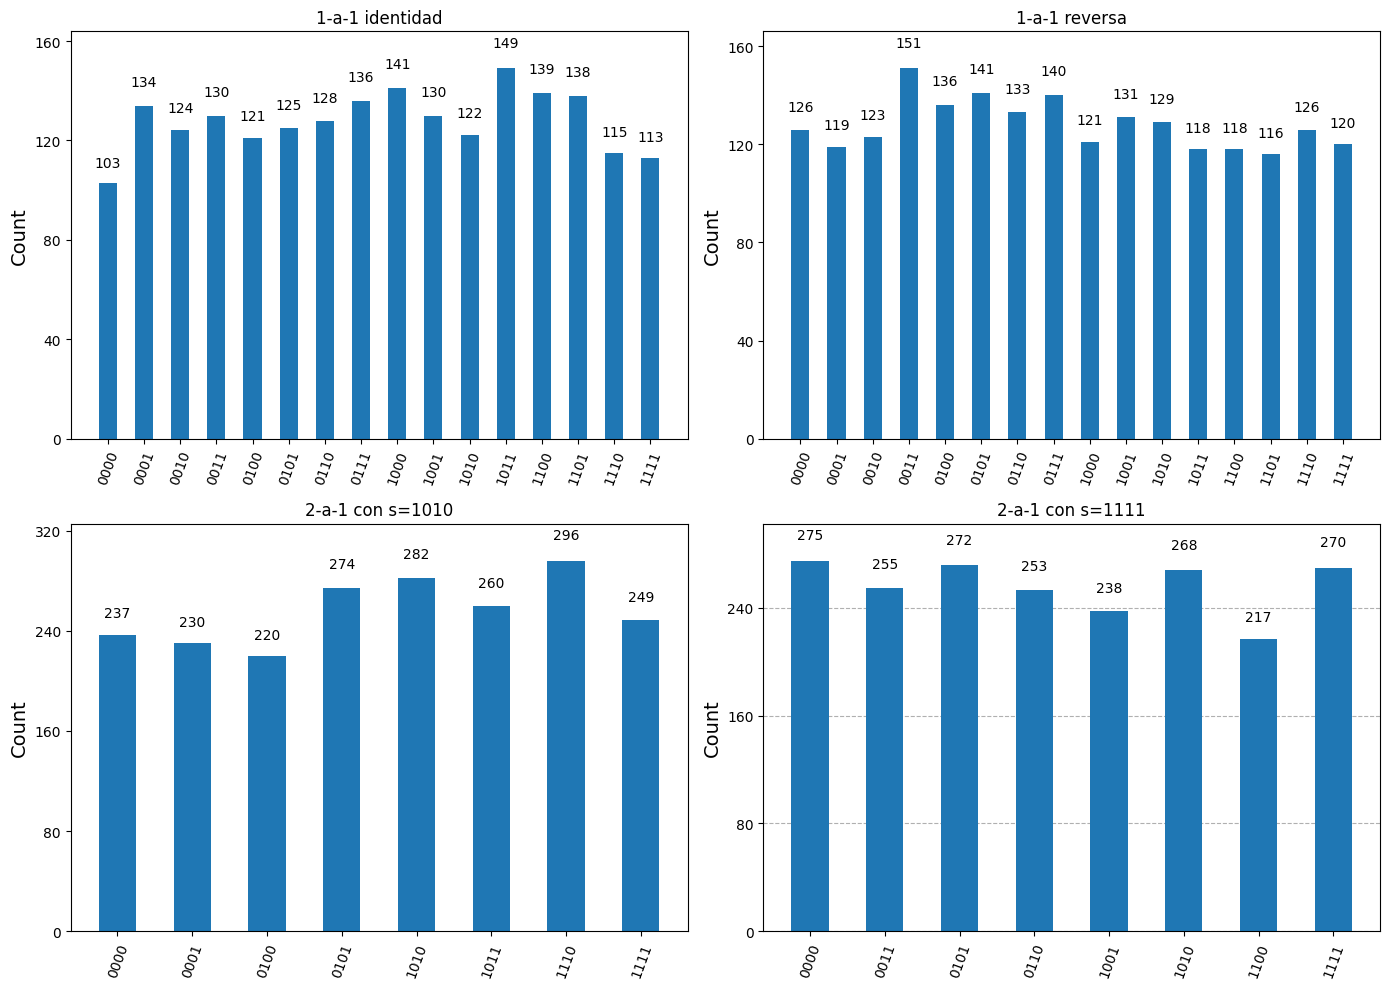

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

names = list(oracle_specs.keys())

for ax, name in zip(axes.flatten(), names):
    plot_histogram(results[name]["counts"], ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Resultados y análisis

A partir de los resultados obtenidos, se observa un comportamiento claramente distinto entre los oráculos 1-a-1 y 2-a-1.

En el caso de las funciones **1-a-1** (identidad y reversa), las mediciones del primer registro se distribuyen prácticamente de forma uniforme entre los 16 posibles strings de 4 bits. Todos los estados aparecen con frecuencias similares (alrededor de 120–150 conteos), lo cual indica que **no existe ninguna restricción sobre los resultados medidos**. Esto es consistente con la teoría, ya que en funciones 1-a-1 no existe un string oculto \(s \neq 0\) que cumpla \(f(x) = f(x \oplus s)\), por lo que el algoritmo de Simon no encuentra ninguna estructura y produce una distribución uniforme.

Por otro lado, en los oráculos **2-a-1**, se observa que las mediciones ya no son uniformes sobre todos los strings posibles, sino que **solo aparecen ciertos subconjuntos de estados**. En ambos casos (para \(s = 1010\) y \(s = 1111\)), únicamente se obtienen 8 resultados distintos en lugar de 16, lo cual coincide con la condición teórica de Simon:
\[
y \cdot s = 0 \mod 2.
\]
Esto significa que los resultados medidos están restringidos a los vectores que son ortogonales al string oculto \(s\) en aritmética módulo 2. La distribución dentro de ese subconjunto es aproximadamente uniforme, pero claramente limitada a la mitad del espacio total.

En particular, para \(s = 1010\), los resultados observados corresponden exactamente a los strings que cumplen la condición de ortogonalidad con dicho vector, y lo mismo ocurre para \(s = 1111\). Esto confirma que el algoritmo está identificando correctamente la estructura de la función y no generando resultados arbitrarios.

En conclusión, los histogramas y conteos obtenidos muestran de manera clara la diferencia fundamental entre funciones 1-a-1 y 2-a-1 en el contexto del algoritmo de Simon. Mientras que en el primer caso se obtiene una distribución uniforme sobre todo el espacio, en el segundo caso los resultados se restringen a un subespacio específico determinado por el periodo oculto. Esto valida experimentalmente el funcionamiento del algoritmo y su capacidad para distinguir entre ambos tipos de funciones.